<a href="https://colab.research.google.com/github/darshanhiteshshah/diabetic-retinopathy/blob/main/mp_phase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base = "/content/drive/MyDrive/dataset-IDRiD/A. Segmentation"

img_dir = base + "/1. Original Images/a. Training Set"
mask_dir = base + "/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms"

patch_img_dir = "/content/patches/images"
patch_mask_dir = "/content/patches/masks"

import os
os.makedirs(patch_img_dir, exist_ok=True)
os.makedirs(patch_mask_dir, exist_ok=True)

In [ ]:
from PIL import Image
import numpy as np
import os

patch_size = 512
stride = 256

positive = []
negative = []

for file in os.listdir(img_dir):
    if not file.endswith(".jpg"):
        continue

    img = Image.open(os.path.join(img_dir, file))
    mask_name = file.replace(".jpg", "_MA.tif")

    mask_path = os.path.join(mask_dir, mask_name)
    if not os.path.exists(mask_path):
        continue

    mask = Image.open(mask_path)

    img = np.array(img)
    mask = np.array(mask)

    h, w = img.shape[:2]
    patch_id = 0

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):

            img_patch = img[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            img_name = f"{file[:-4]}_p{patch_id}.jpg"
            mask_name = f"{file[:-4]}_p{patch_id}.jpg"

            img_path = os.path.join(patch_img_dir, img_name)
            mask_path = os.path.join(patch_mask_dir, mask_name)

            Image.fromarray(img_patch).save(img_path)
            Image.fromarray(mask_patch).save(mask_path)

            if np.sum(mask_patch) > 0:
                positive.append((img_path, mask_path))
            else:
                negative.append((img_path, mask_path))

            patch_id += 1

print("Positive:", len(positive))
print("Negative:", len(negative))

Positive: 3394
Negative: 4706


In [ ]:
import random

negative = random.sample(negative, min(len(negative), 4 * len(positive)))

dataset = positive + negative
random.shuffle(dataset)

print("Final dataset:", len(dataset))

Final dataset: 8100


In [ ]:
import pandas as pd

df = pd.DataFrame(dataset, columns=["image", "mask"])

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("CSV ready")

CSV ready


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 512
BATCH_SIZE = 4

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img.astype(np.float32), mask.astype(np.float32)


def augment(img, mask):
    if np.random.rand() > 0.5:
        img = np.fliplr(img)
        mask = np.fliplr(mask)

    if np.random.rand() > 0.5:
        img = np.flipud(img)
        mask = np.flipud(mask)

    if np.random.rand() > 0.5:
        img = np.rot90(img)
        mask = np.rot90(mask)

    if np.random.rand() > 0.5:
        img = img * (0.8 + 0.4*np.random.rand())
        img = np.clip(img, 0, 1)

    return img, mask


def data_generator(df):
    while True:
        for i in range(0, len(df), BATCH_SIZE):
            batch = df.iloc[i:i+BATCH_SIZE]
            imgs, masks = [], []

            for _, row in batch.iterrows():
                img, mask = load_image_mask(row["image"], row["mask"])
                img, mask = augment(img, mask)

                imgs.append(img)
                masks.append(mask)

            yield np.array(imgs), np.array(masks)

In [ ]:
import tensorflow as tf

def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = tf.keras.layers.MaxPooling2D((2,2))(c)
    return c, p


def decoder_block(x, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet():
    inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

    c1, p1 = encoder_block(inputs, 16)
    c2, p2 = encoder_block(p1, 32)
    c3, p3 = encoder_block(p2, 64)
    c4, p4 = encoder_block(p3, 128)
    c5, p5 = encoder_block(p4, 256)

    b = conv_block(p5, 512)

    d1 = decoder_block(b, c5, 256)
    d2 = decoder_block(d1, c4, 128)
    d3 = decoder_block(d2, c3, 64)
    d4 = decoder_block(d3, c2, 32)
    d5 = decoder_block(d4, c1, 16)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(d5)

    return tf.keras.Model(inputs, outputs)

model = build_unet()

In [ ]:
def weighted_bce(y_true, y_pred):
    weight = 8.0
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    y_true_squeezed = tf.squeeze(y_true, axis=-1)
    weight_map = y_true_squeezed * weight + 1
    return tf.reduce_mean(bce * weight_map)


def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.3, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + 1e-7) / (union + 1e-7)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=weighted_bce,
    metrics=[iou_metric]
)

train_gen = data_generator(train_df)
test_gen = data_generator(test_df)

model.fit(
    train_gen,
    steps_per_epoch=len(train_df)//BATCH_SIZE,
    validation_data=test_gen,
    validation_steps=len(test_df)//BATCH_SIZE,
    epochs=20
)

Epoch 1/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 324s 182ms/step - iou_metric: 0.0025 - loss: 0.3574 - val_iou_metric: 7.7319e-04 - val_loss: 0.2216
Epoch 2/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 300s 185ms/step - iou_metric: 0.0751 - loss: 0.1492 - val_iou_metric: 0.2172 - val_loss: 0.0959
Epoch 3/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 299s 185ms/step - iou_metric: 0.2017 - loss: 0.0706 - val_iou_metric: 0.3288 - val_loss: 0.0532
Epoch 4/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 300s 185ms/step - iou_metric: 0.2227 - loss: 0.0401 - val_iou_metric: 0.3431 - val_loss: 0.0355
Epoch 5/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 299s 185ms/step - iou_metric: 0.2380 - loss: 0.0271 - val_iou_metric: 0.2979 - val_loss: 0.0243
Epoch 6/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 299s 185ms/step - iou_metric: 0.2495 - loss: 0.0218 - val_iou_metric: 0.2990 - val_loss: 0.0245
Epoch 7/20
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 300s 185ms/step - iou_metric: 0.2551 - loss: 0.0192 - val_iou_metric: 0.3103 - val_loss: 0.0216
Epoch 8/20
1620/1620 ━━━━━━━━━

In [ ]:
import numpy as np
import cv2
from PIL import Image
import os

# CHANGE THIS PATH (test images)
test_img_dir = "/content/drive/MyDrive/dataset-IDRiD/A. Segmentation/1. Original Images/b. Testing Set"

output_dir = "predictions"
os.makedirs(output_dir, exist_ok=True)

patch_size = 512
stride = 256

for file in os.listdir(test_img_dir):
    if not file.endswith(".jpg"):
        continue

    print("Processing:", file)

    img_path = os.path.join(test_img_dir, file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]

    # full prediction map
    full_pred = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):

            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patch = cv2.resize(patch, (512, 512))
            patch = patch / 255.0

            patch = np.expand_dims(patch, axis=0)

            pred = model.predict(patch, verbose=0)[0, :, :, 0]

            # merge using MAX (IMPORTANT)
            full_pred[y:y+patch_size, x:x+patch_size] = np.maximum(
                full_pred[y:y+patch_size, x:x+patch_size],
                pred
            )

    # save probability map
    save_path = os.path.join(output_dir, file)
    Image.fromarray((full_pred * 255).astype(np.uint8)).save(save_path)

print("✅ Full image predictions saved!")

Processing: IDRiD_81.jpg
Processing: IDRiD_80.jpg
Processing: IDRiD_76.jpg
Processing: IDRiD_79.jpg
Processing: IDRiD_55.jpg
Processing: IDRiD_59.jpg
Processing: IDRiD_57.jpg
Processing: IDRiD_56.jpg
Processing: IDRiD_58.jpg
Processing: IDRiD_65.jpg
Processing: IDRiD_64.jpg
Processing: IDRiD_60.jpg
Processing: IDRiD_63.jpg
Processing: IDRiD_62.jpg
Processing: IDRiD_61.jpg
Processing: IDRiD_67.jpg
Processing: IDRiD_66.jpg
Processing: IDRiD_68.jpg
Processing: IDRiD_70.jpg
Processing: IDRiD_69.jpg
Processing: IDRiD_71.jpg
Processing: IDRiD_72.jpg
Processing: IDRiD_74.jpg
Processing: IDRiD_73.jpg
Processing: IDRiD_75.jpg
Processing: IDRiD_78.jpg
Processing: IDRiD_77.jpg
✅ Full image predictions saved!


In [ ]:
import numpy as np
import cv2
from PIL import Image
import os

prob_dir = "predictions"          # your output
binary_dir = "final_masks"
os.makedirs(binary_dir, exist_ok=True)

THRESHOLD = 0.3   # 🔥 important (tune later)

for file in os.listdir(prob_dir):
    if not file.endswith(".jpg"):
        continue

    prob = cv2.imread(os.path.join(prob_dir, file), 0)
    prob = prob / 255.0

    binary = (prob > THRESHOLD).astype(np.uint8) * 255

    Image.fromarray(binary).save(os.path.join(binary_dir, file))

print("✅ Binary masks created")

✅ Binary masks created


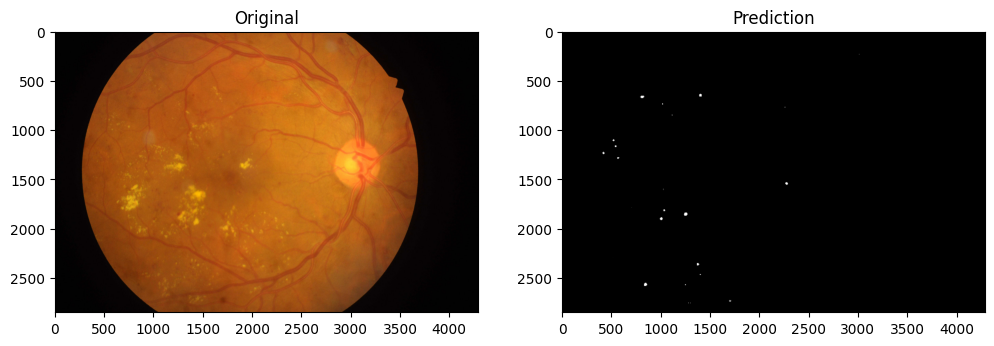

In [ ]:
import matplotlib.pyplot as plt

sample = os.listdir(binary_dir)[0]

img = cv2.imread(os.path.join(test_img_dir, sample))
pred = cv2.imread(os.path.join(binary_dir, sample), 0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')

plt.show()

In [ ]:
gt_dir = "/content/drive/MyDrive/dataset-IDRiD/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/1. Microaneurysms"

In [ ]:
import numpy as np

def compute_iou(gt, pred):
    gt = gt > 0
    pred = pred > 0

    intersection = np.logical_and(gt, pred).sum()
    union = gt.sum() + pred.sum()

    return (2 * intersection + 1e-7) / (union + 1e-7)


ious = []

for file in os.listdir(binary_dir):

    pred_path = os.path.join(binary_dir, file)
    gt_name = file.replace(".jpg", "_MA.tif")
    gt_path = os.path.join(gt_dir, gt_name)

    if not os.path.exists(gt_path):
        continue

    pred = cv2.imread(pred_path, 0)
    gt = cv2.imread(gt_path, 0)

    iou = compute_iou(gt, pred)
    ious.append(iou)

print("✅ Mean IOU:", np.mean(ious))

✅ Mean IOU: 0.2603279609486887


In [ ]:
from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []

for file in os.listdir(binary_dir):

    pred_path = os.path.join(binary_dir, file)
    gt_name = file.replace(".jpg", "_MA.tif")
    gt_path = os.path.join(gt_dir, gt_name)

    if not os.path.exists(gt_path):
        continue

    pred = cv2.imread(pred_path, 0).flatten() > 0
    gt = cv2.imread(gt_path, 0).flatten() > 0

    precisions.append(precision_score(gt, pred))
    recalls.append(recall_score(gt, pred))

print("Precision:", np.mean(precisions))
print("Recall:", np.mean(recalls))

Precision: 0.25723997078949234
Recall: 0.3218653027258018


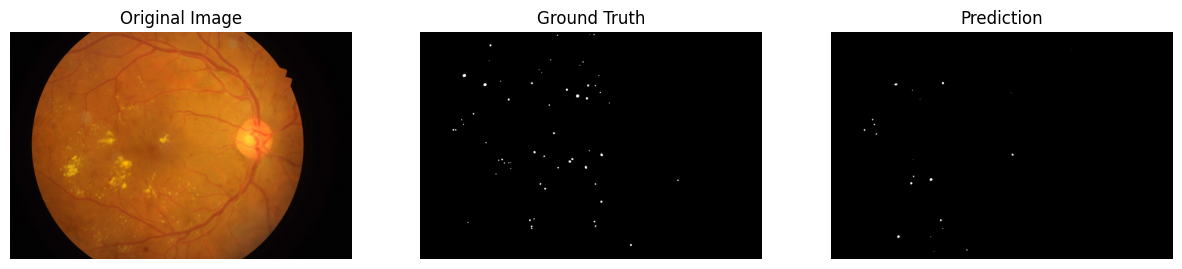

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# paths
pred_dir = "final_masks"
gt_dir = "/content/drive/MyDrive/dataset-IDRiD/A. Segmentation/2. All Segmentation Groundtruths/b. Testing Set/1. Microaneurysms"

# pick one sample
sample = os.listdir(pred_dir)[0]

# load images
img = cv2.imread(os.path.join(test_img_dir, sample))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pred = cv2.imread(os.path.join(pred_dir, sample), 0)

gt_name = sample.replace(".jpg", "_MA.tif")
gt_path = os.path.join(gt_dir, gt_name)

gt = cv2.imread(gt_path, 0)

# plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(gt, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.show()